# Taller de código 2: optimización local

Resolverás el problema de las **8 reinas** con Hill Climbing y Simulated Annealing.

Un estado es una lista donde el índice representa la columna y el valor representa la fila de cada reina. El costo es el número de pares de reinas que se atacan. Buscamos minimizarlo hasta llegar a cero.

Tiempo estimado: **60–75 minutos**.

In [2]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
N = 8

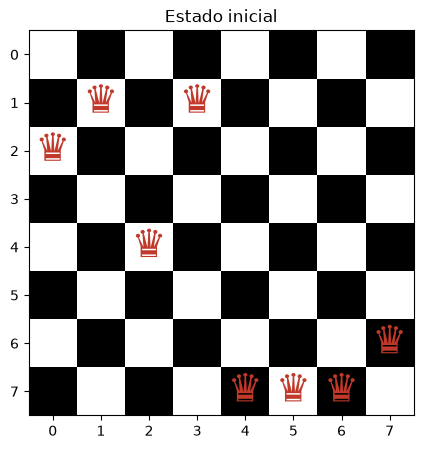

In [3]:
def plot_board(state, title=None):
    n = len(state)
    board = np.fromfunction(lambda row, col: (row + col) % 2, (n, n))
    plt.figure(figsize=(5, 5))
    plt.imshow(board, cmap="Greys", vmin=0, vmax=1)
    for col, row in enumerate(state):
        plt.text(col, row, "♛", ha="center", va="center", fontsize=28, color="#c0392b")
    plt.xticks(range(n)); plt.yticks(range(n))
    plt.title(title or str(state))
    plt.show()

initial_state = [2, 1, 4, 1, 7, 7, 7, 6]
plot_board(initial_state, "Estado inicial")

## Actividad 1 — Función de costo

Cuenta cuántos pares de reinas comparten fila o diagonal. Cada pareja debe contarse una sola vez.

In [ ]:
def conflicts(state):
    """Número de pares de reinas que se atacan."""
    n = len(state)
    total = 0
    # Cada reina ya está en una columna distinta: solo revisamos fila y diagonal.
    # Comparamos con las columnas posteriores para contar cada pareja una vez.
    for col_a in range(n):
        for col_b in range(col_a + 1, n):
            same_row = state[col_a] == state[col_b]
            same_diagonal = abs(state[col_a] - state[col_b]) == col_b - col_a
            if same_row or same_diagonal:
                total += 1
    return total


In [ ]:
assert conflicts([0, 1, 2, 3]) == 6
assert conflicts([1, 3, 0, 2]) == 0
assert conflicts([0, 0, 2, 3]) > 0
print("Pruebas de costo superadas.")

## Actividad 2 — Generación de vecinos

Un vecino se obtiene moviendo una reina a otra fila dentro de su misma columna.

In [4]:
def get_neighbors(state):
    """Genera todos los estados alcanzables moviendo exactamente una reina."""
    n = len(state)
    neighbors = []
    # Cada vecino mueve una sola reina dentro de su columna: n * (n - 1) estados.
    for col in range(n):
        for row in range(n):
            if row == state[col]:
                continue
            neighbor = list(state)
            neighbor[col] = row
            neighbors.append(neighbor)
    return neighbors


In [ ]:
neighbors = get_neighbors([0, 1, 2, 3])
assert len(neighbors) == 4 * 3
assert all(sum(a != b for a, b in zip([0, 1, 2, 3], n)) == 1 for n in neighbors)
print("Pruebas de vecinos superadas.")
print(neighbors)

## Actividad 3 — Hill Climbing

In [7]:
def best_neighbor(state):
    """Devuelve un vecino de costo mínimo y su costo."""
    neighbors = get_neighbors(state)
    costs = [conflicts(neighbor) for neighbor in neighbors]
    best_cost = min(costs)
    # Varios vecinos pueden empatar en el mínimo: elegimos uno al azar para no
    # sesgar siempre la búsqueda hacia las primeras columnas.
    best_states = [n for n, c in zip(neighbors, costs) if c == best_cost]
    return random.choice(best_states), best_cost


def hill_climbing(initial_state, max_steps=200):
    """Minimiza conflicts hasta solución o mínimo local."""
    current = list(initial_state)
    current_cost = conflicts(current)
    history_costs = [current_cost]

    for _ in range(max_steps):
        if current_cost == 0:
            break
        candidate, candidate_cost = best_neighbor(current)
        # Solo aceptamos mejoras estrictas: si el mejor vecino no baja el costo
        # estamos en un mínimo local (o una meseta) y la búsqueda se detiene.
        if candidate_cost >= current_cost:
            break
        current, current_cost = candidate, candidate_cost
        history_costs.append(current_cost)

    return current, history_costs


Estado final: [2, 7, 4, 1, 7, 0, 3, 6]
Costo final: 2
Pasos: 3


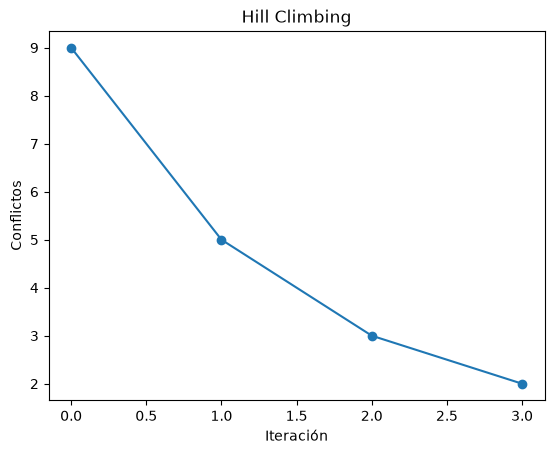

In [8]:
random.seed(RANDOM_STATE)
state_hc, costs_hc = hill_climbing(initial_state)
print("Estado final:", state_hc)
print("Costo final:", conflicts(state_hc))
print("Pasos:", len(costs_hc) - 1)

plt.plot(costs_hc, marker="o")
plt.xlabel("Iteración"); plt.ylabel("Conflictos")
plt.title("Hill Climbing")
plt.show()

## Actividad 4 — Simulated Annealing

Estamos minimizando. Define:

$$\Delta = C_{nuevo}-C_{actual}.$$

Si $\Delta\leq 0$, el movimiento no empeora. Si $\Delta>0$, se acepta con probabilidad:

$$P=\exp\left(-\frac{\Delta}{T}\right).$$

In [ ]:
def acceptance_probability(current_cost, new_cost, temperature):
    """Probabilidad de aceptar el movimiento actual -> nuevo."""
    delta = new_cost - current_cost
    # Un movimiento que mejora o empata nunca se rechaza.
    if delta <= 0:
        return 1.0
    if temperature <= 0:
        return 0.0
    # Empeorar es menos probable cuanto mayor sea delta o más fría la temperatura.
    return math.exp(-delta / temperature)


def simulated_annealing(initial_state, initial_temperature=10.0,
                        cooling_rate=0.995, min_temperature=1e-3,
                        max_steps=10_000):
    """Minimiza conflicts permitiendo empeoramientos ocasionales."""
    current = list(initial_state)
    current_cost = conflicts(current)
    history_costs = [current_cost]
    temperature = initial_temperature

    for _ in range(max_steps):
        if current_cost == 0 or temperature < min_temperature:
            break
        # A diferencia de hill climbing no evaluamos los n * (n - 1) vecinos:
        # proponemos uno solo al azar.
        candidate = random.choice(get_neighbors(current))
        candidate_cost = conflicts(candidate)
        prob = acceptance_probability(current_cost, candidate_cost, temperature)
        if random.random() < prob:
            current, current_cost = candidate, candidate_cost
        # Registramos el costo aceptado y enfriamos de forma geométrica.
        history_costs.append(current_cost)
        temperature *= cooling_rate

    return current, history_costs


In [ ]:
assert acceptance_probability(5, 4, 1.0) == 1.0
assert 0 < acceptance_probability(4, 5, 1.0) < 1

random.seed(RANDOM_STATE)
state_sa, costs_sa = simulated_annealing(initial_state)
print("Estado final:", state_sa)
print("Costo final:", conflicts(state_sa))
plot_board(state_sa, f"Simulated Annealing — costo {conflicts(state_sa)}")

## Actividad 5 — Comparación en varios reinicios

          algoritmo  tasa_exito  costo_promedio  peor_costo
      Hill Climbing    0.100000        1.366667           3
Simulated Annealing    0.933333        0.066667           1


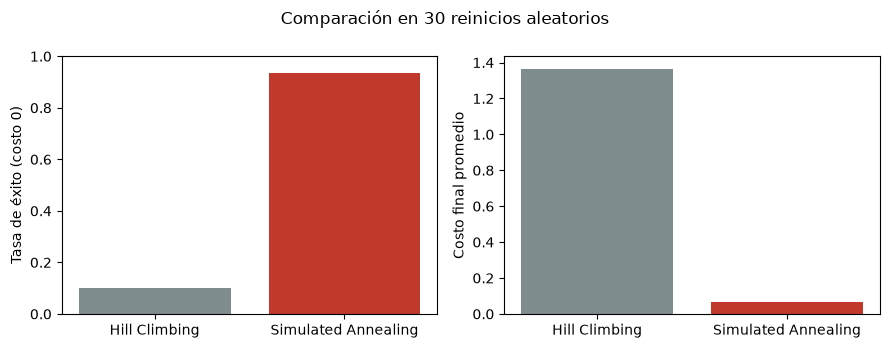

In [11]:
def random_state(n=N):
    """Estado aleatorio: una reina por columna, en una fila cualquiera."""
    return [random.randrange(n) for _ in range(n)]


N_RUNS = 30
random.seed(RANDOM_STATE)
# Los dos algoritmos parten de los mismos tableros: así la comparación es
# pareada y ninguno se beneficia de que le tocaran estados más fáciles.
start_states = [random_state() for _ in range(N_RUNS)]

algorithms = {
    "Hill Climbing": hill_climbing,
    "Simulated Annealing": simulated_annealing,
}

rows = []
for name, algorithm in algorithms.items():
    random.seed(RANDOM_STATE)
    final_costs = [conflicts(algorithm(state)[0]) for state in start_states]
    rows.append({
        "algoritmo": name,
        "tasa_exito": np.mean([cost == 0 for cost in final_costs]),
        "costo_promedio": np.mean(final_costs),
        "peor_costo": max(final_costs),
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
colors = ["#7f8c8d", "#c0392b"]
axes[0].bar(comparison["algoritmo"], comparison["tasa_exito"], color=colors)
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Tasa de éxito (costo 0)")
axes[1].bar(comparison["algoritmo"], comparison["costo_promedio"], color=colors)
axes[1].set_ylabel("Costo final promedio")
fig.suptitle(f"Comparación en {N_RUNS} reinicios aleatorios")
plt.tight_layout(); plt.show()


## Preguntas de análisis

1. ¿Por qué Hill Climbing puede detenerse con costo mayor que cero?
2. ¿Qué permite a Simulated Annealing escapar de mínimos locales?
3. Si el enfriamiento es demasiado rápido, ¿a cuál algoritmo empieza a parecerse?
4. ¿Qué ocurre si la temperatura permanece muy alta?

## Checklist

- [ ] Implementé costo y vecinos.
- [ ] Hill Climbing acepta solo mejoras.
- [ ] Simulated Annealing puede aceptar empeoramientos.
- [ ] Comparé ambos algoritmos en múltiples ejecuciones.